# End-to-End Test

## Import Functions to Test

In [1]:
from raag_midi_gen.tokenizer import encode_input, encode_target

## Import Helper Functions

In [2]:
import torch
import muspy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from raag_midi_gen.datasets import midi_files_dataset

In [3]:
# test_clip_filename = 'Taraana - Antra 2.0.mid'        # EASY
test_clip_filename = 'Aeri Aali - Sthaayi 1.1_2.mid'  # HARD

## Get Data Sample

In [4]:
midi_files_dataset = midi_files_dataset.get_dataset()
original_midi = midi_files_dataset[test_clip_filename][-1]

[<Axes: xlabel='time (beat)', ylabel='\n\npitch'>]

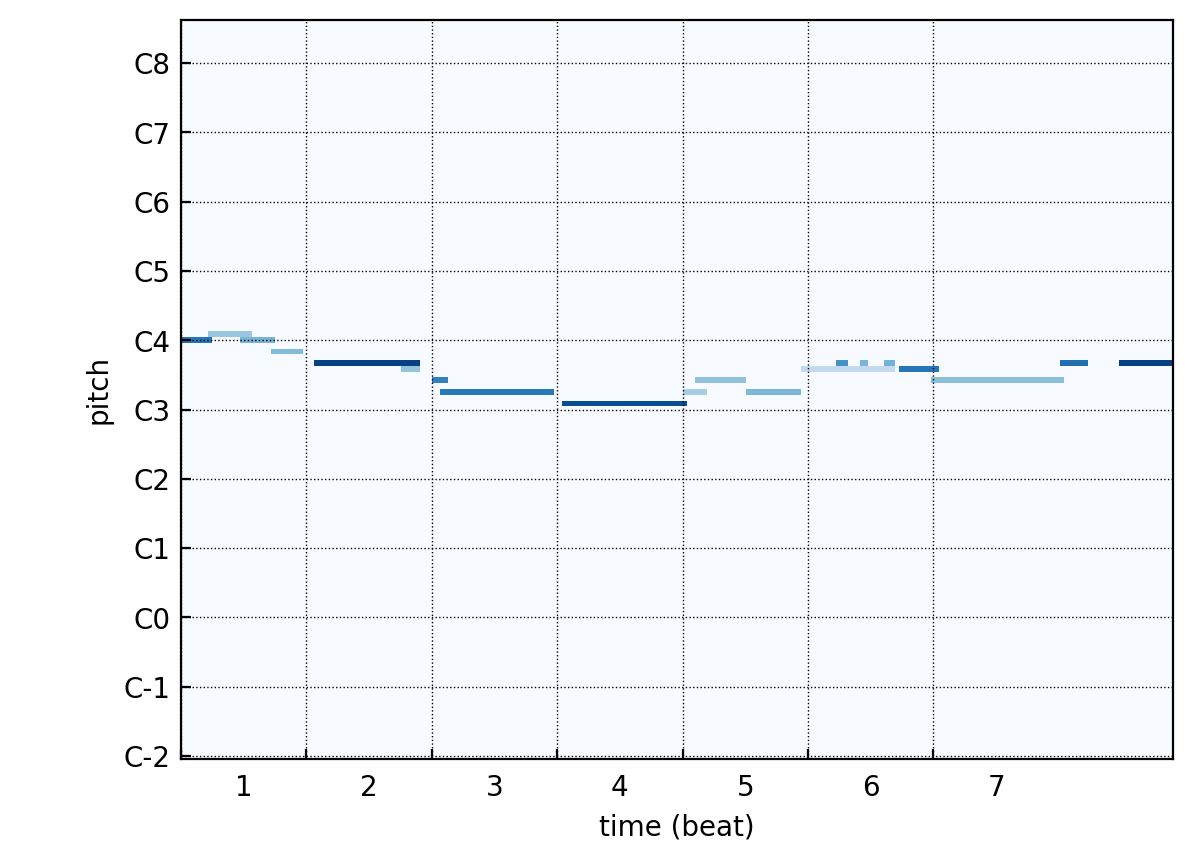

In [5]:
muspy.show_pianoroll(original_midi)

In [6]:
original_midi.tracks[0].notes

[Note(time=0, pitch=72, duration=24, velocity=93),
 Note(time=21, pitch=73, duration=33, velocity=49),
 Note(time=45, pitch=72, duration=27, velocity=60),
 Note(time=69, pitch=70, duration=24, velocity=56),
 Note(time=102, pitch=68, duration=81, velocity=119),
 Note(time=168, pitch=67, duration=15, velocity=51),
 Note(time=192, pitch=65, duration=12, velocity=87),
 Note(time=198, pitch=63, duration=87, velocity=91),
 Note(time=291, pitch=61, duration=96, velocity=113),
 Note(time=384, pitch=63, duration=18, velocity=44),
 Note(time=393, pitch=65, duration=39, velocity=52),
 Note(time=432, pitch=63, duration=42, velocity=58),
 Note(time=474, pitch=67, duration=72, velocity=33),
 Note(time=501, pitch=68, duration=9, velocity=78),
 Note(time=519, pitch=68, duration=6, velocity=59),
 Note(time=537, pitch=68, duration=9, velocity=61),
 Note(time=549, pitch=67, duration=30, velocity=93),
 Note(time=573, pitch=65, duration=102, velocity=54),
 Note(time=672, pitch=68, duration=21, velocity=96)

## Input Encoding

### Get Encoding

In [7]:
input_encoding = encode_input(original_midi)

In [8]:
print(input_encoding['pitch'].shape)
print(input_encoding['octave'].shape)
print(input_encoding['velocity'].shape)
print(input_encoding['event_type'].shape)
print(input_encoding['position'].shape)

torch.Size([768])
torch.Size([768])
torch.Size([768, 1])
torch.Size([768])
torch.Size([768, 6])


### Plot Encoding

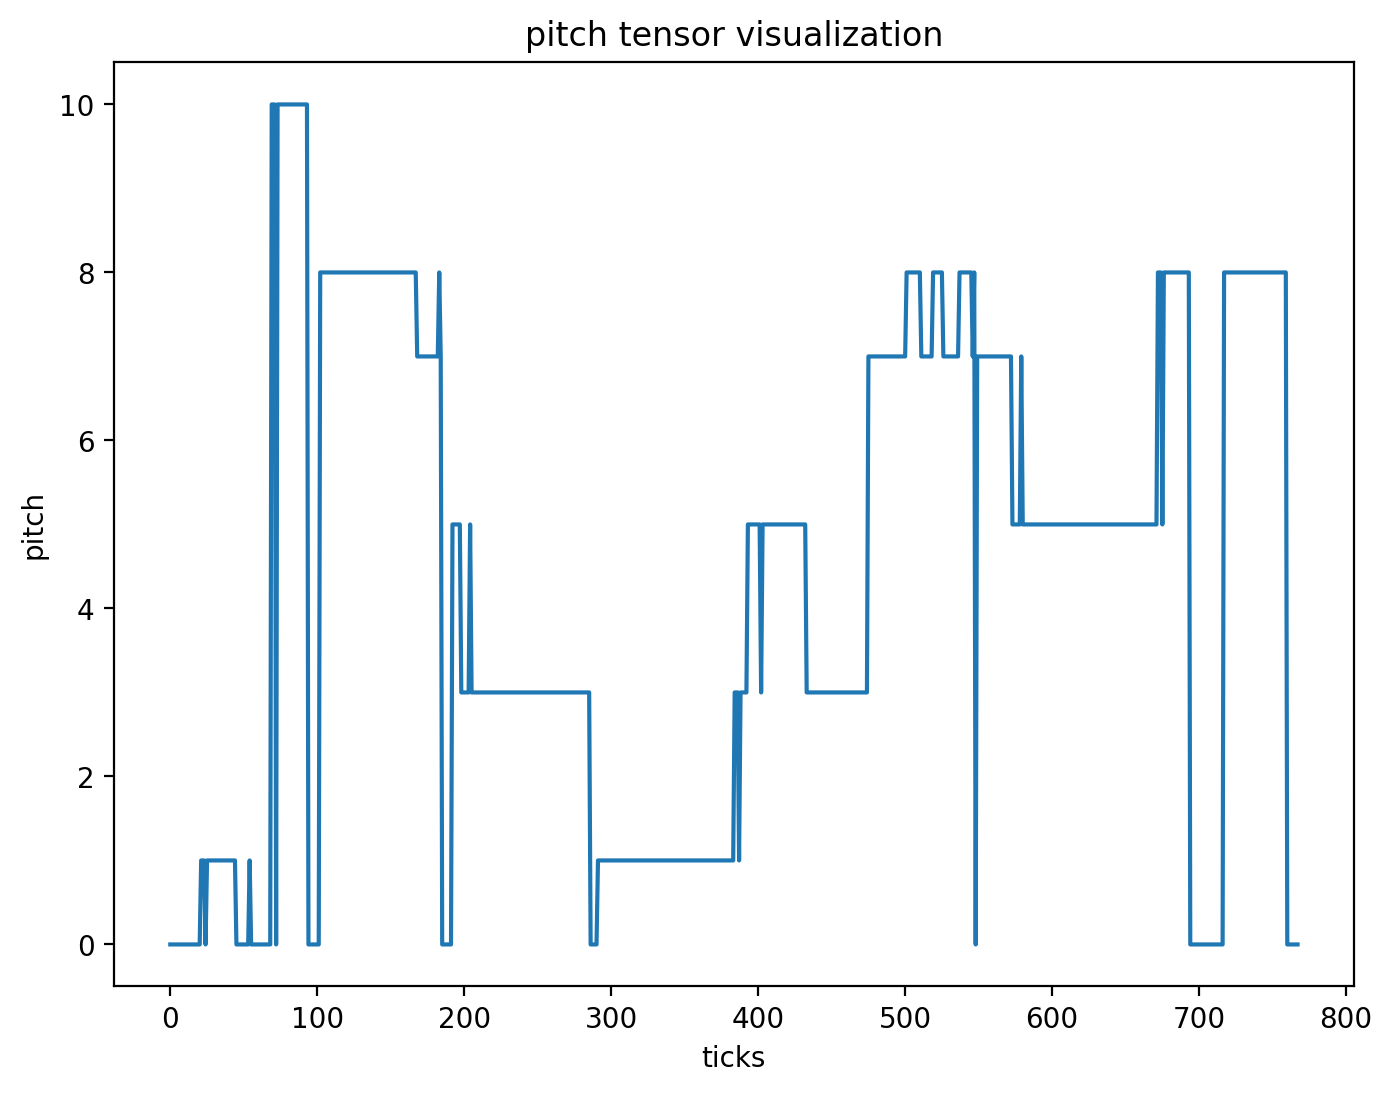

In [9]:
key = 'pitch'

numpy_tensor = input_encoding[key].detach().cpu().numpy()

plt.figure(figsize=(8, 6))
sns.lineplot(numpy_tensor)
plt.title(f'{key} tensor visualization')
plt.xlabel('ticks')
plt.ylabel(key)
plt.show()

[<Axes: xlabel='time (beat)', ylabel='\n\npitch'>]

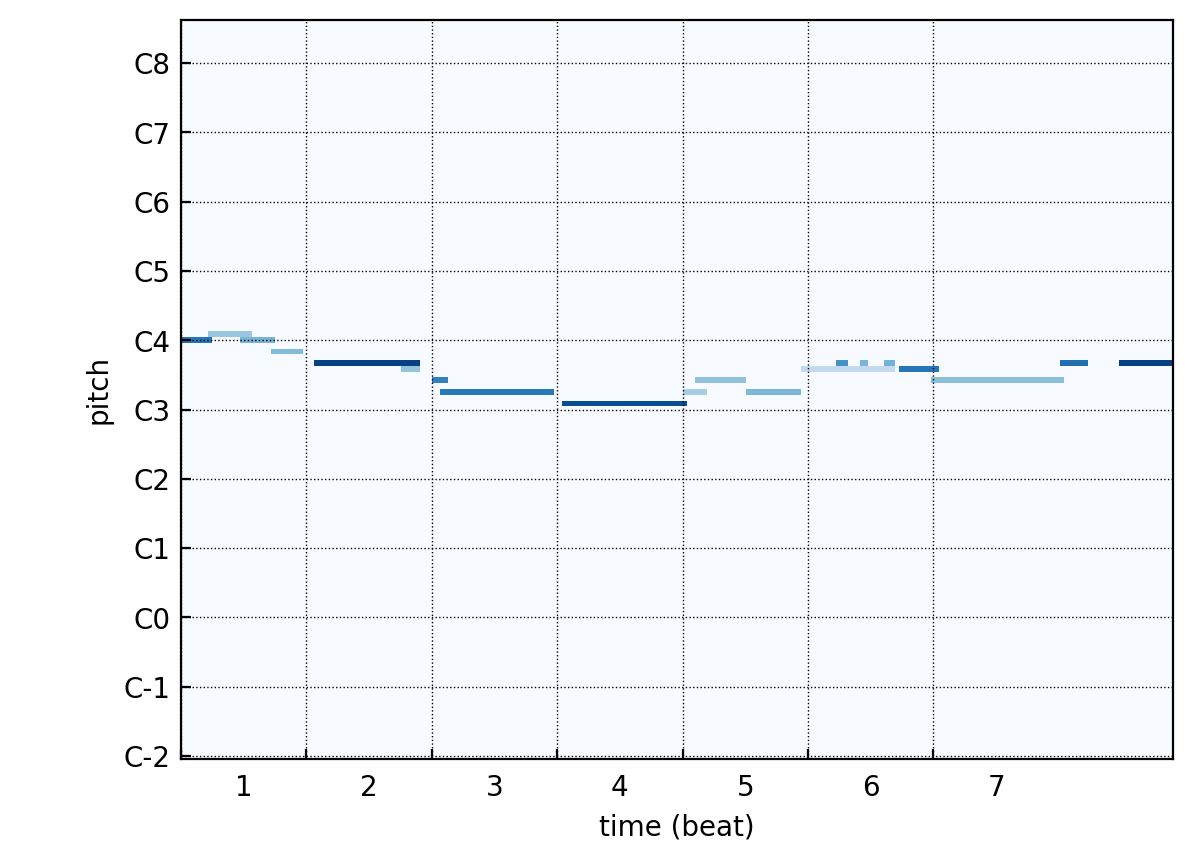

In [10]:
muspy.show_pianoroll(original_midi)

## Target Encoding

### Get Encoding

In [11]:
target_encoding = encode_target(original_midi)

In [12]:
print(target_encoding['pitch'].shape)
print(target_encoding['octave'].shape)
print(target_encoding['velocity'].shape)
print(target_encoding['event_type'].shape)

torch.Size([768, 14])
torch.Size([768, 13])
torch.Size([768, 1])
torch.Size([768, 5])


### Plot Encoding

In [13]:
from raag_midi_gen.tokenization.decoding import _get_midi_pitches

midi_pitches = _get_midi_pitches(target_encoding['pitch'], target_encoding['octave'])

plt.figure(figsize=(8, 6))
sns.lineplot(midi_pitches)
plt.xlabel('ticks')
plt.ylabel(key)
plt.show()

ModuleNotFoundError: No module named 'raag_midi_gen.tokenization'

In [ ]:
muspy.show_pianoroll(original_midi)